# UK Opinion Polls: Matplotlib vs Seaborn

This notebook demonstrates two different approaches to plotting time series data for multiple groups:

1. **The "old way"**: Using a `for` loop with `matplotlib` to iterate over each party and plot manually
2. **The "tidy way"**: Melting the data into long format and using `seaborn` to handle the grouping automatically

The key insight is that `seaborn` (and the grammar of graphics philosophy) expects **tidy/long data** — one observation per row — rather than wide data with one column per group. Converting to long format with `pd.melt()` unlocks powerful, concise visualisations.

The data is scraped live from Wikipedia: https://en.wikipedia.org/wiki/Opinion_polling_for_the_next_United_Kingdom_general_election

## Data Collection & Setup

The next cell scrapes the Wikipedia opinion polling page live, parses the HTML tables for each year found under the "National poll results" section, cleans the percentage values, and saves the result as a CSV. It also defines the official party HEX colours and human-readable party name labels used throughout the notebook.

In [1]:
"""
UK Opinion Polls Scraper and Visualiser
Scrapes national poll tables from Wikipedia (all available years, detected
dynamically) and plots a scatterplot + LOESS smooth per party using official
party HEX colours.
"""

import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from bs4 import BeautifulSoup
from datetime import datetime
from statsmodels.nonparametric.smoothers_lowess import lowess



In [4]:
# ── 1. FETCH PAGE ─────────────────────────────────────────────────────────────
# We set a browser-like User-Agent header so Wikipedia doesn't reject the request

URL = "https://en.wikipedia.org/wiki/Opinion_polling_for_the_next_United_Kingdom_general_election"
HEADERS = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}

print("Fetching Wikipedia page...")
response = requests.get(URL, headers=HEADERS, timeout=30)
response.raise_for_status()   # raises an exception for HTTP 4xx/5xx errors
soup = BeautifulSoup(response.content, "html.parser")

# ── 2. DISCOVER YEAR SECTIONS DYNAMICALLY ────────────────────────────────────
#
# Wikipedia adds a new h3 heading for each year as polling data accumulates.
# Rather than hard-coding [2024, 2025, ...] we walk the DOM and collect any
# bare 4-digit year headings that appear inside the "National poll results" h2.

def find_national_poll_years(soup: BeautifulSoup) -> set[str]:
    """Return the set of year strings found under 'National poll results'."""
    in_national = False
    years: set[str] = set()

    for el in soup.find_all(["h2", "h3", "h4"]):
        text = el.get_text(strip=True)
        if el.name == "h2":
            # Toggle the flag whenever we enter or leave an h2 section
            in_national = "National poll results" in text
        elif in_national and re.fullmatch(r"\d{4}", text):
            # Only collect headings that are exactly a 4-digit year
            years.add(text)

    return years

target_years = find_national_poll_years(soup)
print(f"Year sections found on page: {sorted(target_years)}")

# ── 3. PARSE DATE ─────────────────────────────────────────────────────────────

def parse_date(raw: str, year: int) -> datetime | None:
    """
    Parse a date string, keeping the LAST date when a range is given.
      '18 Feb'      → 18 Feb <year>
      '13–17 Feb'   → 17 Feb <year>   (en dash)
      '19-23 Dec'   → 23 Dec <year>   (ASCII hyphen)

    We use the end date of a fieldwork range so that the poll is plotted
    at the point when results would first be available.
    """
    # Normalise both en-dash (–) and em-dash (—) to a plain hyphen
    s = raw.strip().replace("\u2013", "-").replace("\u2014", "-")
    last_part = s.split("-")[-1].strip()  # take everything after the last hyphen
    try:
        return datetime.strptime(f"{last_part} {year}", "%d %b %Y")
    except ValueError:
        return None

# ── 4. SCRAPE NATIONAL POLL TABLES ───────────────────────────────────────────

# Columns we want to extract — these match the Wikipedia table header text
PARTY_COLS = ["Lab", "Con", "Ref", "LD", "Grn", "SNP", "PC"]

def clean_pct(val: str) -> float | None:
    """Strip a trailing '%' and convert to float; return None if unparseable."""
    try:
        return float(val.replace("%", "").strip())
    except ValueError:
        return None

def strip_refs(text: str) -> str:
    """Remove Wikipedia footnote markers like [1], [2] from strings."""
    return re.sub(r"\[\d+\]", "", text).strip()

records = []
current_heading = "Unknown"

# Walk all headings and tables together so we know which year section
# each table belongs to before we try to parse it
for el in soup.find_all(["h2", "h3", "h4", "table"]):
    if el.name in ("h2", "h3", "h4"):
        current_heading = el.get_text(strip=True)
    elif el.name == "table" and "wikitable" in el.get("class", []):
        # Skip tables that are not inside a target year section
        if current_heading not in target_years:
            continue
        year = int(current_heading)
        rows = el.find_all("tr")
        if not rows:
            continue

        # Use the first row as column headers
        col_names = [th.get_text(strip=True) for th in rows[0].find_all("th")]

        for row in rows[1:]:
            cells = row.find_all(["th", "td"])
            # Skip rows that are too short to be data rows (e.g. sub-headers)
            if len(cells) < 8:
                continue
            vals = [c.get_text(strip=True) for c in cells]
            if not vals[0] or vals[0] in ("Date(s)conducted",):
                continue

            # Build a dict from column names → cell values for this row
            row_dict = {col: val for col, val in zip(col_names, vals)}
            row_dict["year"] = year
            row_dict["date"] = parse_date(row_dict.get("Date(s)conducted", ""), year)
            row_dict["Pollster"] = strip_refs(row_dict.get("Pollster", ""))

            # Convert party vote share strings to floats in-place
            for party in PARTY_COLS:
                if party in row_dict:
                    row_dict[party] = clean_pct(row_dict[party])

            records.append(row_dict)

df = pd.DataFrame(records)
df = df.dropna(subset=["date"])          # remove rows where date parsing failed
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

years_in_data = sorted(df["year"].unique())
print(f"Total rows scraped: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Polls: {len(df)}")


# ── 5. SAVE RAW DATA ──────────────────────────────────────────────────────────

df.to_csv("../data/uk_opinion_polls.csv", index=False)
print("Saved uk_opinion_polls.csv")

# ── 6. OFFICIAL PARTY HEX COLOURS ────────────────────────────────────────────
# Using official/standard brand colours for each party.
# SNP's official yellow (#FDF38E) is too pale on a white background,
# so we use a darker gold instead.

PARTY_COLOURS = {
    "Lab": "#E4003B",   # Labour red
    "Con": "#0087DC",   # Conservative blue
    "Ref": "#12B6CF",   # Reform UK teal
    "LD":  "#FAA61A",   # Liberal Democrats amber
    "Grn": "#02A95B",   # Green Party green
    "SNP": "#D4B000",   # SNP gold (official #FDF38E is too pale on white)
    "PC":  "#3F8428",   # Plaid Cymru dark green
}

# Human-readable labels used in plot legends and the melted dataframe
PARTY_LABELS = {
    "Lab": "Labour",
    "Con": "Conservative",
    "Ref": "Reform UK",
    "LD":  "Lib Dems",
    "Grn": "Green",
    "SNP": "SNP",
    "PC":  "Plaid Cymru",
}

Fetching Wikipedia page...
Year sections found on page: ['2024', '2025', '2026']
Total rows scraped: 377
Date range: 2024-07-12 → 2026-02-23
Polls: 377
Saved uk_opinion_polls.csv


In [5]:
df.tail(10) # last (most recent)10 opinion polls

,Date(s)conducted,Pollster,Client,Area,Samplesize,Lab,Con,Ref,LD,Grn,SNP,PC,Others,Lead,year,date
367,6–10 Feb,More in Common,N/A,GB,"2,035",23.0,21.0,30.0,12.0,10.0,2.0,1.0,2%,7,2026,2026-02-10
368,11 Feb,Find Out Now,N/A,GB,"1,394",16.0,19.0,29.0,11.0,18.0,3.0,1.0,4%,10,2026,2026-02-11
369,4–12 Feb,JL Partners[a],The Sun,GB,"2,006",23.0,19.0,31.0,12.0,9.0,2.0,1.0,6%,8,2026,2026-02-12
370,11–12 Feb,Techne,N/A,UK,"1,644",17.0,19.0,30.0,14.0,15.0,2.0,NaN,3%,11,2026,2026-02-12
371,13–16 Feb,Good Growth Foundation,N/A,GB,"1,432",21.0,20.0,28.0,12.0,12.0,3.0,1.0,3%,7,2026,2026-02-16
372,15–16 Feb,YouGov,N/A,GB,"2,384",19.0,18.0,24.0,13.0,17.0,3.0,1.0,4%,5,2026,2026-02-16
373,13–17 Feb,More in Common,N/A,GB,"2,108",22.0,21.0,28.0,11.0,12.0,3.0,1.0,2%,6,2026,2026-02-17
374,18 Feb,Find Out Now,N/A,GB,"2,178",16.0,16.0,28.0,10.0,18.0,3.0,2.0,7%,10,2026,2026-02-18
375,20–23 Feb,More in Common,N/A,GB,"2,015",22.0,20.0,28.0,14.0,11.0,2.0,1.0,2%,6,2026,2026-02-23
376,22–23 Feb,YouGov,N/A,GB,"2,325",18.0,18.0,24.0,14.0,17.0,3.0,1.0,4%,6,2026,2026-02-23


## Approach 1: Matplotlib with a `for` loop

The traditional approach: iterate over each party manually, extracting its column and plotting it. This is explicit and familiar, but verbose. Notice how much boilerplate is needed:
- Manually manage colours
- Manually compute LOESS smoothing via `statsmodels` and plot the result
- Manually handle the legend
- Repeat nearly identical code for each group

This works fine but doesn't scale well — if you had 10 parties, you'd just be writing more of the same code.

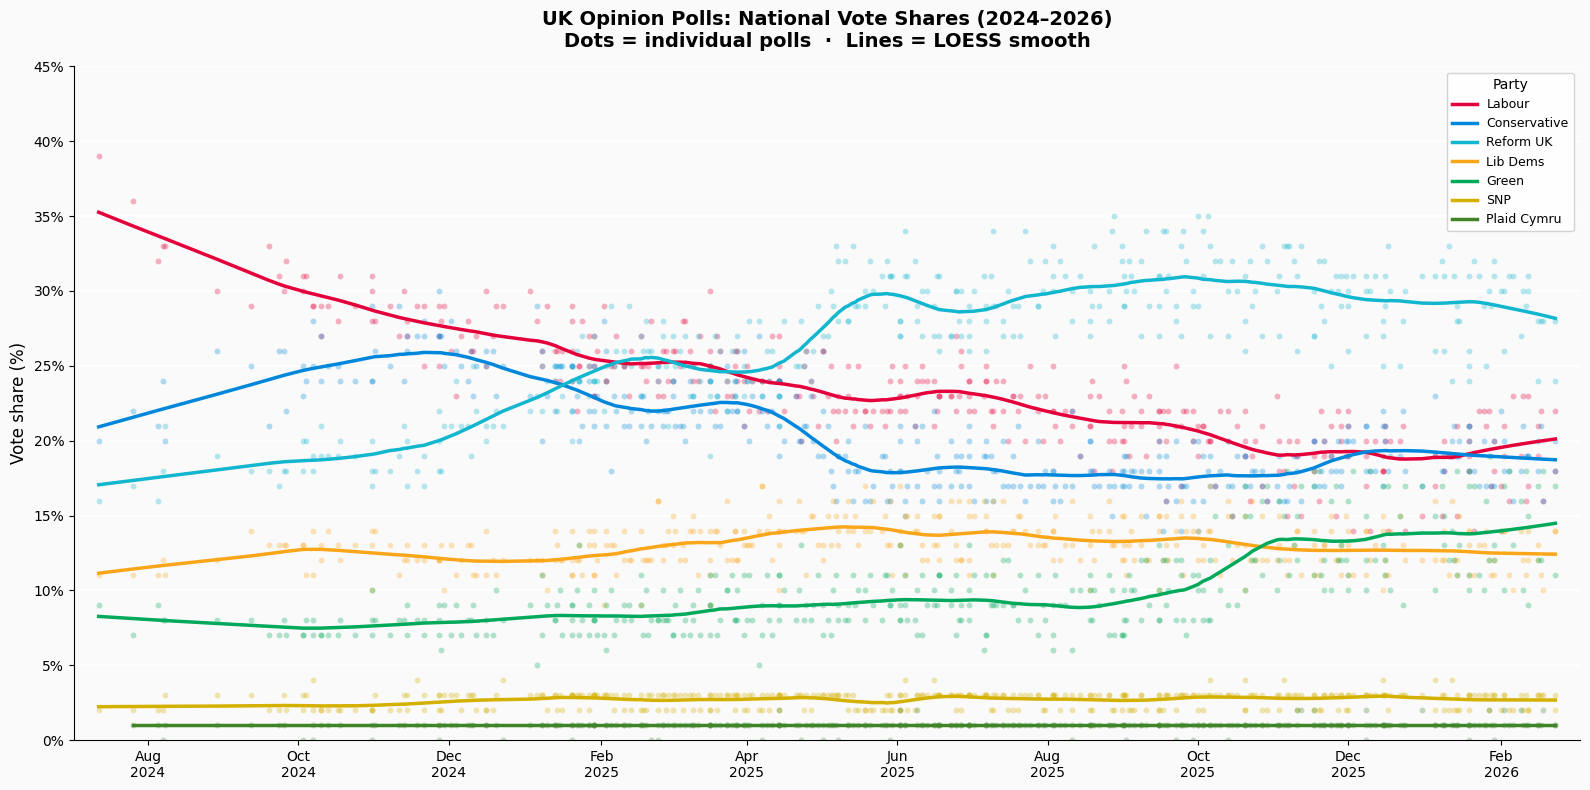

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor("#FAFAFA")  # off-white background for the whole figure
ax.set_facecolor("#FAFAFA")          # match the axes area

# Convert all dates to matplotlib's internal float format once upfront,
# so we can use them with lowess() which requires numeric x values
date_num = mdates.date2num(df["date"])

for party, colour in PARTY_COLOURS.items():
    # Skip if this party column doesn't exist in the scraped data
    if party not in df.columns:
        continue

    # Build a boolean mask to exclude NaN values for this party
    # (not all pollsters report every party)
    mask    = df[party].notna()
    x_num   = date_num[mask]
    y       = df.loc[mask, party].values
    x_dates = df.loc[mask, "date"].values

    # Skip parties with too few data points for a meaningful smooth
    if len(y) < 5:
        continue

    # ── Scatter: individual poll results ─────────────────────────────────────
    # label="_nolegend_" suppresses these points from the legend;
    # the legend will be driven by the smooth lines below instead
    ax.scatter(x_dates, y, color=colour, alpha=0.30, s=18,
               linewidths=0, label="_nolegend_", zorder=2)

    # ── LOESS smooth ─────────────────────────────────────────────────────────
    # statsmodels lowess() is the Python equivalent of ggplot2's geom_smooth().
    # frac=0.12 means each local regression uses 12% of the data — a relatively
    # narrow bandwidth that follows the trend without over-smoothing.
    # We sort by x first because lowess expects ordered input.
    sort_idx = np.argsort(x_num)
    smoothed = lowess(y[sort_idx], x_num[sort_idx], frac=0.12, return_sorted=True)

    # smoothed[:,0] is x (as floats), smoothed[:,1] is the smoothed y values.
    # We convert x back to datetime objects for the axis to display correctly.
    ax.plot(
        mdates.num2date(smoothed[:, 0]), smoothed[:, 1],
        color=colour, linewidth=2.5,
        label=PARTY_LABELS[party], zorder=3,
    )

# ── Axis formatting ───────────────────────────────────────────────────────────
year_range = f"{min(years_in_data)}–{max(years_in_data)}"

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))        # tick every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))        # 'Aug\n2024' style
ax.set_xlim(df["date"].min() - pd.Timedelta(days=10),
            df["date"].max() + pd.Timedelta(days=10))               # small padding
ax.set_ylim(0, 45)
ax.set_ylabel("Vote share (%)", fontsize=12)
ax.set_title(
    f"UK Opinion Polls: National Vote Shares ({year_range})\n"
    "Dots = individual polls  ·  Lines = LOESS smooth",
    fontsize=14, fontweight="bold", pad=14,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))  # '25%' format
ax.grid(axis="y", color="white", linewidth=1.2, zorder=1)   # subtle white gridlines
ax.spines[["top", "right"]].set_visible(False)               # cleaner look
ax.legend(title="Party", title_fontsize=10, fontsize=9,
          framealpha=0.85, loc="upper right")

plt.tight_layout()
# plt.savefig("uk_opinion_polls.png", dpi=150, bbox_inches="tight") # Uncomment line to save plot
plt.show()


## The Tidy Data Transformation: `pd.melt()`

Before plotting with Seaborn, we need to **reshape** the data from **wide** to **long** format.

**Wide format** (what we have): one column per party
```
date        Lab  Con  Ref  LD   Grn
2024-07-12  39   20   16   11   9
2024-07-26  36   22   17   11   7
```

**Long/tidy format** (what Seaborn wants): one row per observation
```
date        party  vote_share
2024-07-12  Lab    39
2024-07-12  Con    20
2024-07-12  Ref    16
2024-07-26  Lab    36
...
```

This is the **tidy data** principle (Wickham, 2014): each variable is a column, each observation is a row. Once the data is tidy, the `hue` parameter in Seaborn does all the grouping work for us.

In [8]:
# Melt from wide → long using method chaining.
#
# Wide format has one column per party (Lab, Con, Ref, ...).
# Long/tidy format has one row per (date, party) observation.
# Seaborn's hue= parameter expects this long format — it maps a categorical
# column to colour, rather than expecting you to loop over columns yourself.

df_long = (
    df
    .melt(
        id_vars='date',           # keep 'date' as an identifier column
        value_vars=PARTY_COLS,    # unpivot these party columns into rows
        var_name='party',         # new column holding the party abbreviation
        value_name='vote_share'   # new column holding the % value
    )
    .dropna(subset=['vote_share'])   # remove rows where a pollster didn't report that party
    .assign(
        # Add a human-readable label column by mapping abbreviations → full names
        party_label=lambda d: d['party'].map(PARTY_LABELS)
    )
    .sort_values('date')
    .reset_index(drop=True)
)

print(f"Wide shape: {df.shape}  →  Long shape: {df_long.shape}")
df_long.tail(20)


Wide shape: (377, 16)  →  Long shape: (2579, 4)


,date,party,vote_share,party_label
2559,2026-02-18,PC,2.0,Plaid Cymru
2560,2026-02-18,Ref,28.0,Reform UK
2561,2026-02-18,Con,16.0,Conservative
2562,2026-02-18,Lab,16.0,Labour
2563,2026-02-18,LD,10.0,Lib Dems
2564,2026-02-18,Grn,18.0,Green
2565,2026-02-23,Con,20.0,Conservative
2566,2026-02-23,LD,14.0,Lib Dems
2567,2026-02-23,LD,14.0,Lib Dems
2568,2026-02-23,Grn,17.0,Green


## Approach 2: Seaborn with Melted Long Data

Now the scatter plot is dramatically simpler. By passing `hue='party_label'` to `sns.scatterplot`, Seaborn handles:
- Assigning colours to each party automatically from the `palette` dict
- Iterating over all parties in one call — no loop needed for the scatter

For the LOESS smooth lines we still loop, but the loop body is much cleaner — there is no NaN handling, no date-to-float conversion for the scatter, and no manual colour lookup. All of that is already encoded in the tidy dataframe.

One seaborn-specific wrinkle: `sns.scatterplot` and `ax.plot` don't share a legend system, so we set `legend=False` on the scatter and collect the line artist returned by each `ax.plot` call, then pass those handles to `ax.legend()` manually at the end.

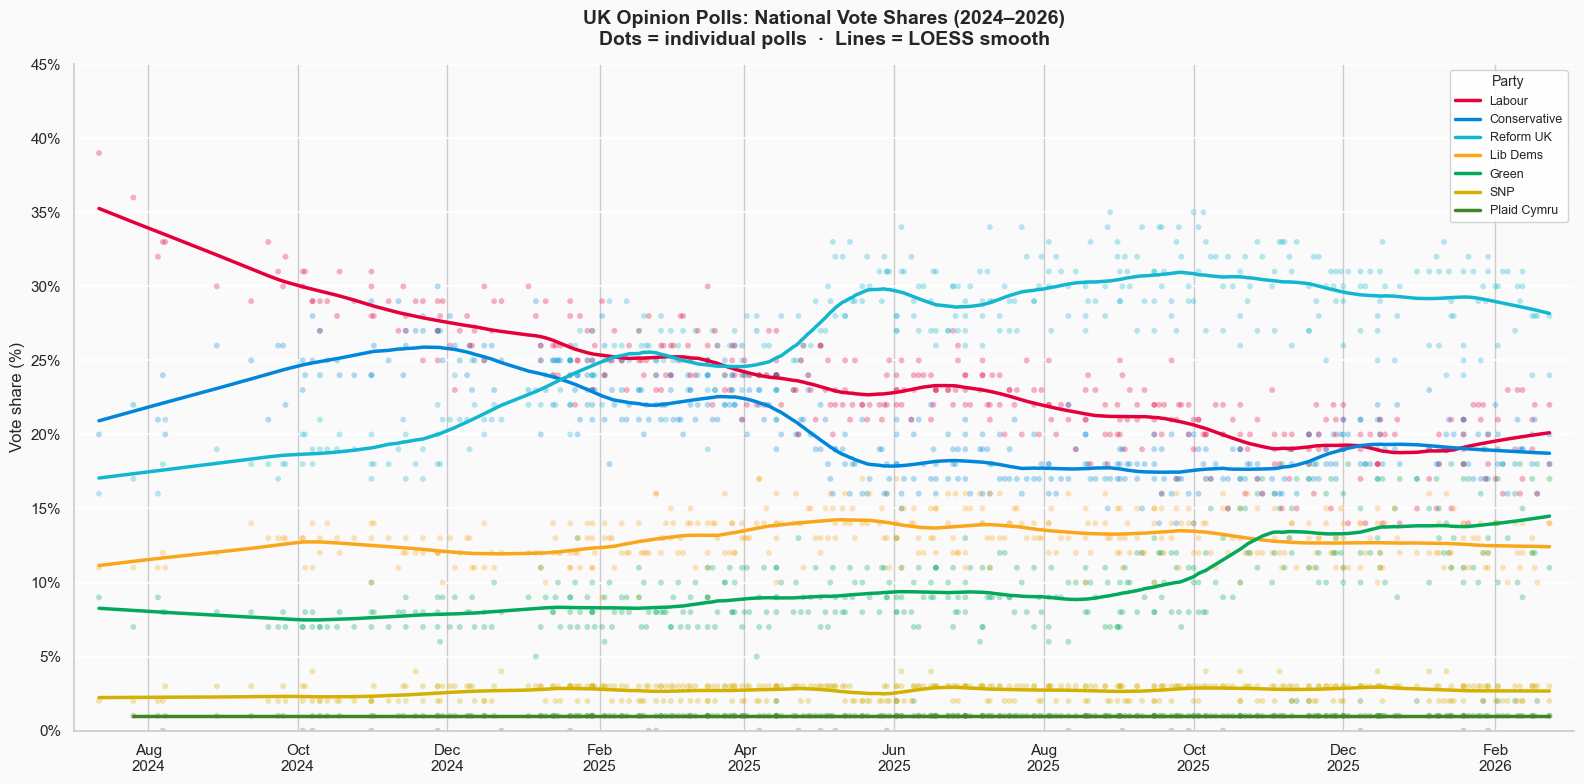

In [9]:
sns.set_theme(style="whitegrid")

# Build a palette dict keyed by full party name (matching party_label column)
palette = {PARTY_LABELS[k]: v for k, v in PARTY_COLOURS.items()}
year_range = f"{min(years_in_data)}–{max(years_in_data)}"

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# ── Scatter: all parties in one call ─────────────────────────────────────────
# hue= maps party_label → colour automatically using the palette dict.
# legend=False here because the legend will be driven by the smooth lines below.
sns.scatterplot(
    data=df_long,
    x="date", y="vote_share",
    hue="party_label",
    palette=palette,
    alpha=0.30, s=18, linewidths=0,
    legend=False,
    ax=ax, zorder=2,
)

# ── LOESS lines + legend handle collection ────────────────────────────────────
# We use statsmodels lowess() directly (rather than sns.regplot(lowess=True))
# because regplot doesn't expose the frac bandwidth parameter.
# ax.plot() returns a list of Line2D objects; the comma unpacks the single item
# so `line` is a Line2D we can pass to ax.legend() later.
legend_handles = []

for party_label, colour in palette.items():
    # Method-chain to filter, clean, and sort in one expression
    subset = (
        df_long
        .query("party_label == @party_label")
        .dropna(subset=["vote_share"])
        .sort_values("date")
    )
    if len(subset) < 5:
        continue

    # Convert dates to floats for lowess, then back to datetimes for the plot
    x_num    = mdates.date2num(subset["date"])
    smoothed = lowess(subset["vote_share"].values, x_num, frac=0.12, return_sorted=True)

    line, = ax.plot(
        mdates.num2date(smoothed[:, 0]), smoothed[:, 1],
        color=colour, linewidth=2.5, zorder=3,
    )
    legend_handles.append((line, party_label))   # store handle + label for legend

# ── Axis formatting ───────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_xlim(df_long["date"].min() - pd.Timedelta(days=10),
            df_long["date"].max() + pd.Timedelta(days=10))
ax.set_ylim(0, 45)
ax.set_xlabel("")
ax.set_ylabel("Vote share (%)", fontsize=12)
ax.set_title(
    f"UK Opinion Polls: National Vote Shares ({year_range})\n"
    "Dots = individual polls  ·  Lines = LOESS smooth",
    fontsize=14, fontweight="bold", pad=14,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.grid(axis="y", color="white", linewidth=1.2, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

# Build the legend from the Line2D handles collected during the loop above.
# We can't use seaborn's auto-legend here because the smooth lines were drawn
# with ax.plot(), which operates outside seaborn's legend machinery.
ax.legend(
    [h for h, _ in legend_handles],
    [l for _, l in legend_handles],
    title="Party", title_fontsize=10, fontsize=9,
    framealpha=0.85, loc="upper right",
)

plt.tight_layout()
# plt.savefig("uk_opinion_polls.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary: Key Differences

| | Matplotlib + `for` loop | Seaborn + `melt` |
|---|---|---|
| **Data shape** | Wide (one column per party) | Long/tidy (one row per observation) |
| **Scatter** | `ax.scatter()` inside a loop | `sns.scatterplot(hue=)` — one call |
| **Colours** | Manually looked up per loop iteration | `hue=` + `palette=` handles it |
| **LOESS smooth** | `statsmodels.lowess()` + `ax.plot()` inside loop | Same — `sns.regplot(lowess=True)` can't accept a custom `frac` |
| **Legend** | Driven by `label=` on `ax.plot()` | Manually built from collected `Line2D` handles |
| **New group?** | Add another loop iteration | Just appears automatically in scatter |
| **Code volume** | More (scatter + smooth fully manual) | Less (scatter is one call; loop is just for LOESS) |

### When to use each

**Matplotlib for loops** give you fine-grained control and are excellent when you need highly customised per-group styling or when each group genuinely needs different treatment.

**Seaborn + tidy data** shines when you have a consistent visual encoding across groups (same geom, same aesthetics, just different colours). The scatter is reduced to a single call, and `hue=` makes the intent of the code immediately readable. The LOESS loop remains, but it is shorter because all the data wrangling has moved into the tidy dataframe.